In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [3]:
# Install and import libraries, mount Google Drive
!pip install -q opencv-python-headless matplotlib seaborn scikit-learn tensorflow

In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import json
import pickle
from datetime import datetime
import zipfile
import glob

In [13]:
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))
if tf.config.list_physical_devices('GPU'):
    print("GPU Name:", tf.test.gpu_device_name())
else:
    print("No GPU detected. Training will run on CPU.")

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
GPU Name: /device:GPU:0


I0000 00:00:1785517967.997467      58 gpu_device.cc:2020] Created device /device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785517967.999178      58 gpu_device.cc:2020] Created device /device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [14]:
# Verify GPU is working
!nvidia-smi

Fri Jul 31 17:13:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   59C    P0             29W /   70W |     105MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [15]:
# Dataset path on Kaggle
dataset_path = '/kaggle/input/datasets/victorjacobasuquo/road-crack-dataset/Road Anomaly Detection System Dataset/Road Images/road_img'

# If automatic detection fails, try to find it
import os
if not os.path.exists(dataset_path):
    base_dir = '/kaggle/input/'
    for item in os.listdir(base_dir):
        item_path = os.path.join(base_dir, item)
        if os.path.isdir(item_path):
            # Check if it contains image directories
            for sub in os.listdir(item_path):
                sub_path = os.path.join(item_path, sub)
                if os.path.isdir(sub_path):
                    images = [f for f in os.listdir(sub_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                    if images:
                        dataset_path = item_path
                        break
            if os.path.exists(dataset_path):
                break

print(f"Dataset path: {dataset_path}")

# Verify dataset structure
if os.path.exists(dataset_path):
    print("\nDataset contents:")
    class_dirs = []
    for item in os.listdir(dataset_path):
        item_path = os.path.join(dataset_path, item)
        if os.path.isdir(item_path):
            img_count = len([f for f in os.listdir(item_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            class_dirs.append((item, img_count))
            print(f"  {item}: {img_count} images")
else:
    print(f"Dataset not found. Please check the path.")

Dataset path: /kaggle/input/datasets/victorjacobasuquo/road-crack-dataset/Road Anomaly Detection System Dataset/Road Images/road_img

Dataset contents:
  Pothole: 300 images
  Plain: 300 images


In [16]:
# Set up working directories
WORK_DIR = '/kaggle/working/'
MODEL_DIR = os.path.join(WORK_DIR, 'models')
OUTPUT_DIR = os.path.join(WORK_DIR, 'outputs')
PLOT_DIR = os.path.join(OUTPUT_DIR, 'plots')
METRIC_DIR = os.path.join(OUTPUT_DIR, 'metrics')

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(METRIC_DIR, exist_ok=True)

print(f"Model directory: {MODEL_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Model directory: /kaggle/working/models
Output directory: /kaggle/working/outputs


In [17]:
# Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Get class names
class_names = []
for item in os.listdir(dataset_path):
    item_path = os.path.join(dataset_path, item)
    if os.path.isdir(item_path):
        images = [f for f in os.listdir(item_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if images:
            class_names.append(item)

print("Classes:", class_names)

Classes: ['Pothole', 'Plain']


In [18]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    seed=SEED,
    shuffle=True
)

validation_generator = val_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    seed=SEED,
    shuffle=False
)

print("\nClass mapping:", train_generator.class_indices)
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {validation_generator.samples}")

Found 480 images belonging to 2 classes.
Found 120 images belonging to 2 classes.

Class mapping: {'Plain': 0, 'Pothole': 1}
Training samples: 480
Validation samples: 120


# sample images


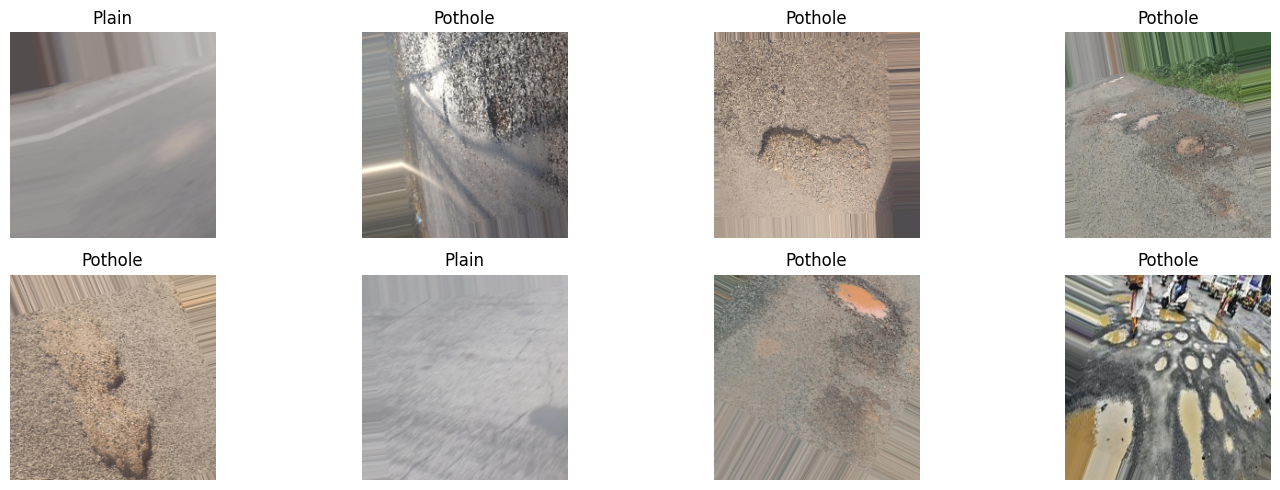

Sample images saved to /kaggle/working/outputs/plots/sample_images.png


In [19]:
def plot_sample_images(generator, num_samples=8):
    images, labels = next(generator)
    class_names = list(generator.class_indices.keys())
    
    plt.figure(figsize=(15, 5))
    for i in range(min(num_samples, len(images))):
        plt.subplot(2, 4, i+1)
        plt.imshow(images[i])
        plt.title(f"{class_names[int(labels[i])]}")
        plt.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, 'sample_images.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Sample images saved to {PLOT_DIR}/sample_images.png")

plot_sample_images(train_generator)

# Build Cnn

In [20]:
def build_cnn_model(input_shape=(224, 224, 3)):
    model = models.Sequential([
        # First Convolutional Block
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Second Convolutional Block
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Third Convolutional Block
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Fully Connected Layers
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        
        layers.Dense(1, activation='sigmoid')
    ])
    return model

model = build_cnn_model()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1785518374.535055      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785518374.536796      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,785,793 (98.36 MB)

 Trainable params: 25,784,833 (98.36 MB)

 Non-trainable params: 960 (3.75 KB)

In [21]:
callbacks_list = [
    callbacks.ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, 'pothole_model.keras'),
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

In [23]:
EPOCHS = 15

print("=" * 15)
print("Starting model training...")
print("=" * 15)

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE,
    callbacks=callbacks_list,
    verbose=1
)

print("=" * 15)
print("Training completed!")
print("=" * 15)

Starting model training...
Epoch 1/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9197 - loss: 0.2342
Epoch 1: val_loss improved from None to 5.09159, saving model to /kaggle/working/models/pothole_model.keras

Epoch 1: finished saving model to /kaggle/working/models/pothole_model.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 59s 4s/step - accuracy: 0.9208 - loss: 0.2534 - val_accuracy: 0.6250 - val_loss: 5.0916 - learning_rate: 0.0010
Epoch 2/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9008 - loss: 0.3244
Epoch 2: val_loss improved from 5.09159 to 5.03340, saving model to /kaggle/working/models/pothole_model.keras

Epoch 2: finished saving model to /kaggle/working/models/pothole_model.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 52s 3s/step - accuracy: 0.9125 - loss: 0.2694 - val_accuracy: 0.6250 - val_loss: 5.0334 - learning_rate: 0.0010
Epoch 3/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9417 - loss: 0.1605
Epoch 3: val_loss improved from 5.03340 to 0.58572, saving model to /ka

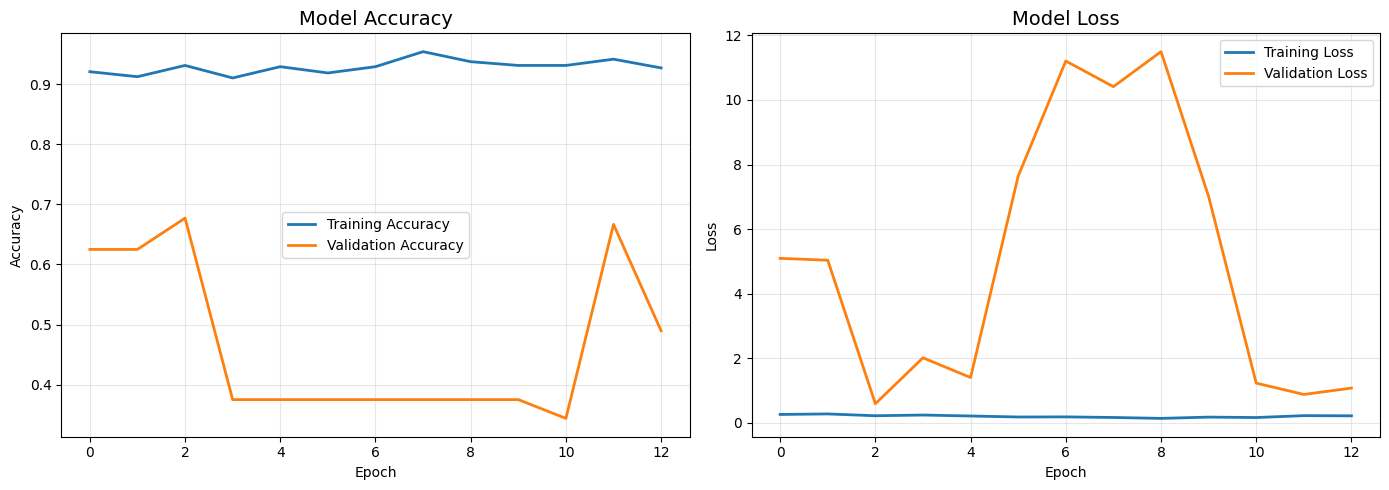

Training curves saved to /kaggle/working/outputs/plots/training_curves.png


In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
ax1.set_title('Model Accuracy', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax2.set_title('Model Loss', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Training curves saved to {PLOT_DIR}/training_curves.png")

In [25]:
val_loss, val_accuracy = model.evaluate(validation_generator, verbose=1)
print(f"\nValidation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

validation_generator.reset()
predictions = model.predict(validation_generator, verbose=1)
predicted_classes = (predictions > 0.5).astype(int).flatten()
true_classes = validation_generator.classes[:len(predicted_classes)]

class_names = list(validation_generator.class_indices.keys())
print("\n" + "=" * 50)
print("Classification Report:")
print("=" * 50)
report = classification_report(true_classes, predicted_classes, target_names=class_names)
print(report)

with open(os.path.join(METRIC_DIR, 'classification_report.txt'), 'w') as f:
    f.write(report)
print(f"\nReport saved to {METRIC_DIR}/classification_report.txt")

4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.6000 - loss: 0.6632

Validation Loss: 0.6632
Validation Accuracy: 0.6000
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step

Classification Report:
              precision    recall  f1-score   support

       Plain       0.56      1.00      0.71        60
     Pothole       1.00      0.20      0.33        60

    accuracy                           0.60       120
   macro avg       0.78      0.60      0.52       120
weighted avg       0.78      0.60      0.52       120


Report saved to /kaggle/working/outputs/metrics/classification_report.txt


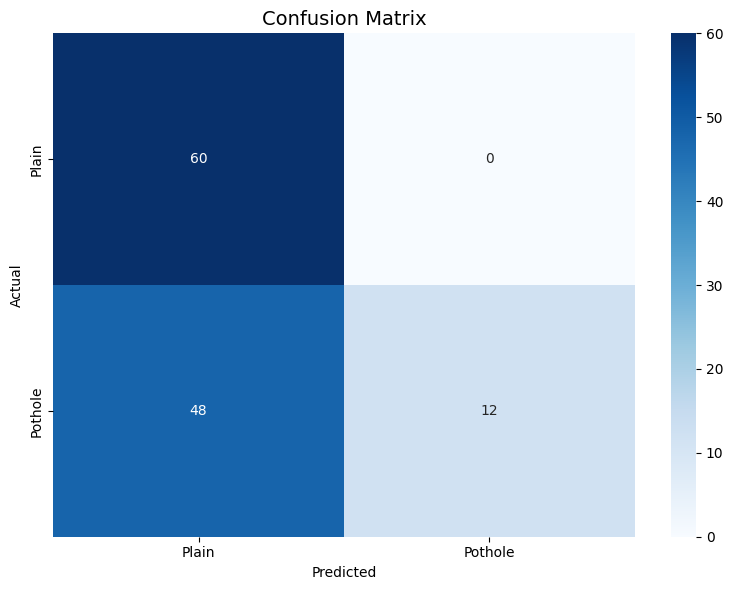

Confusion matrix saved to /kaggle/working/outputs/plots/confusion_matrix.png


In [26]:
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Confusion matrix saved to {PLOT_DIR}/confusion_matrix.png")

In [27]:
# Save in H5 format
model.save(os.path.join(MODEL_DIR, 'pothole_model.h5'))
print(f"Model saved: {MODEL_DIR}/pothole_model.h5")

# Save label encoder
with open(os.path.join(MODEL_DIR, 'label_encoder.pkl'), 'wb') as f:
    pickle.dump(train_generator.class_indices, f)
print(f"Label encoder saved: {MODEL_DIR}/label_encoder.pkl")

# Save config
config = {
    'model_name': 'Pothole Detection CNN',
    'task': 'Binary Classification - Pothole vs Intact Asphalt',
    'dataset': 'Road Anomaly Detection System Dataset',
    'input_shape': list(IMG_SIZE) + [3],
    'classes': class_names,
    'validation_accuracy': float(val_accuracy),
    'validation_loss': float(val_loss),
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'tensorflow_version': tf.__version__
}

with open(os.path.join(MODEL_DIR, 'model_config.json'), 'w') as f:
    json.dump(config, f, indent=4)
print(f"Config saved: {MODEL_DIR}/model_config.json")

Model saved: /kaggle/working/models/pothole_model.h5
Label encoder saved: /kaggle/working/models/label_encoder.pkl
Config saved: /kaggle/working/models/model_config.json


In [28]:
def load_and_predict(img_path, model, class_names):
    from tensorflow.keras.preprocessing import image
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0
    
    pred = model.predict(img_array, verbose=0)
    pred_class = int(pred[0][0] > 0.5)
    confidence = pred[0][0] if pred_class == 1 else 1 - pred[0][0]
    
    return class_names[pred_class], confidence, pred[0][0]

print("Prediction function ready!")
print("Usage: load_and_predict('path/to/image.jpg', model, class_names)")

Prediction function ready!
Usage: load_and_predict('path/to/image.jpg', model, class_names)


In [29]:
# Zip and download all artifacts
import zipfile
from IPython.display import display, FileLink

def create_zip_and_download(folder_path, zip_name):
    with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, os.path.dirname(folder_path))
                zipf.write(file_path, arcname)
    print(f"Created: {zip_name}")
    display(FileLink(zip_name))

# Zip models
create_zip_and_download(MODEL_DIR, os.path.join(WORK_DIR, 'models.zip'))

# Zip outputs
create_zip_and_download(OUTPUT_DIR, os.path.join(WORK_DIR, 'outputs.zip'))

print("\nClick the links above to download artifacts.")

Created: /kaggle/working/models.zip


/kaggle/working/models.zip

Created: /kaggle/working/outputs.zip


/kaggle/working/outputs.zip


Click the links above to download your artifacts.
